In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('C:/Users/viryu/Downloads/Top Mentors/Gen AI Session 1/Assignment/10. Random Forests/Fraud_check.csv')

In [2]:
df.head()
df.isnull().sum()
df.describe()
df.dtypes
df.shape

(600, 6)

In [3]:
df.head(5)

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban
0,NO,Single,68833,50047,10,YES
1,YES,Divorced,33700,134075,18,YES
2,NO,Married,36925,160205,30,YES
3,YES,Single,50190,193264,15,YES
4,NO,Married,81002,27533,28,NO


In [4]:
for col in df.select_dtypes(include='object').columns:
    print(f'{col}: {df[col].unique()}')

Undergrad: ['NO' 'YES']
Marital.Status: ['Single' 'Divorced' 'Married']
Urban: ['YES' 'NO']


In [5]:
df['Risky'] = df['Taxable.Income'].apply(lambda x : 'Risky' if x<=30000 else 'Good')
print(df["Risky"].value_counts())

Risky
Good     476
Risky    124
Name: count, dtype: int64


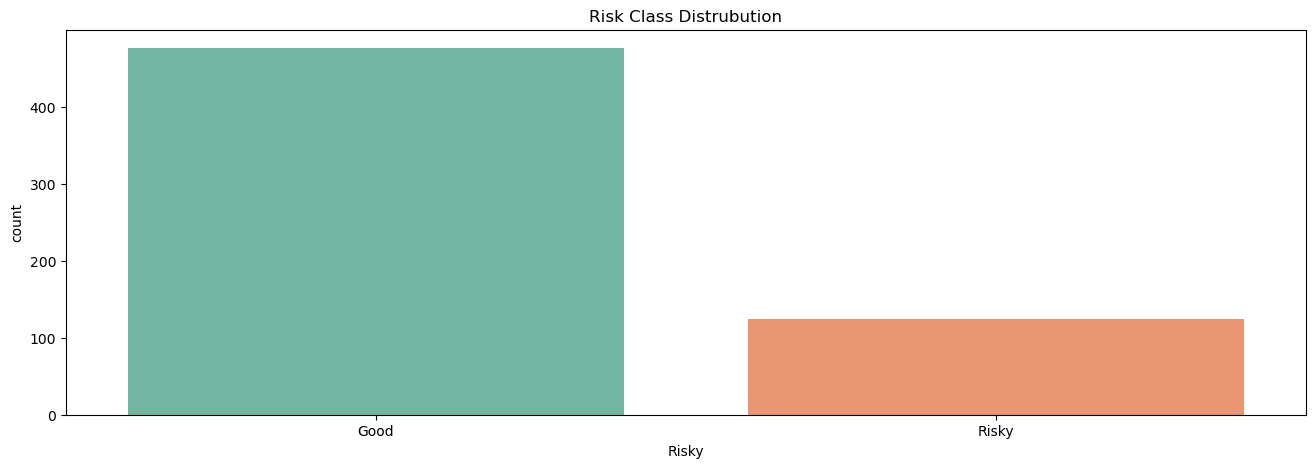

In [6]:
plt.figure(figsize=(16,5))
sns.countplot( x = "Risky", data = df, palette = "Set2")
plt.title("Risk Class Distrubution")
plt.show()

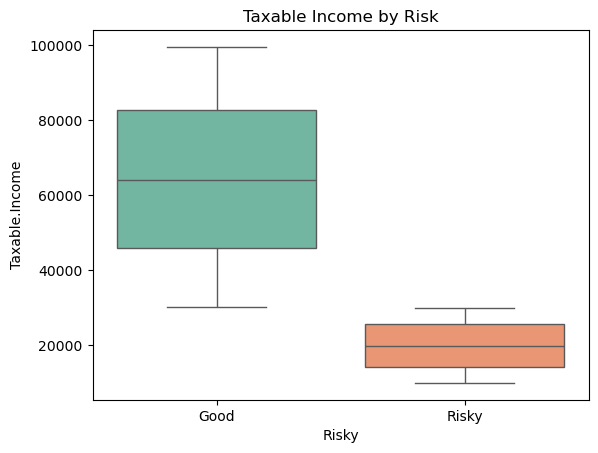

In [7]:
sns.boxplot(x='Risky', y='Taxable.Income', data=df, palette='Set2')
plt.title('Taxable Income by Risk')
plt.show()

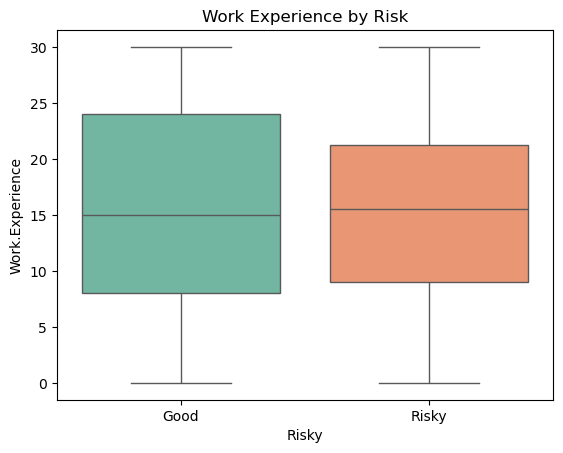

In [8]:
# Plot 3 - Work Experience by Risk
sns.boxplot(x='Risky', y='Work.Experience', data=df, palette='Set2')
plt.title('Work Experience by Risk')
plt.show()

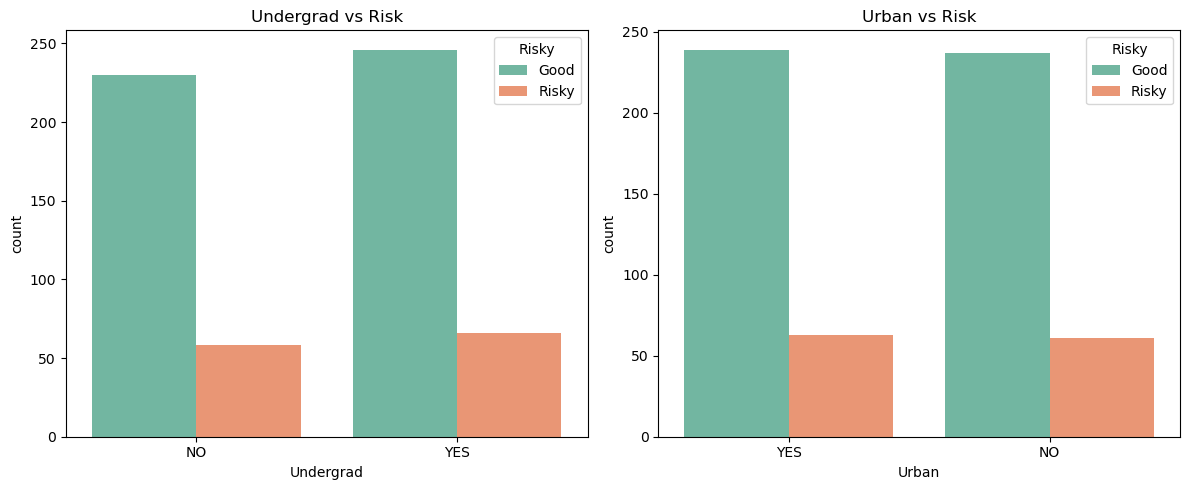

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x='Undergrad', hue='Risky', data=df, palette='Set2', ax=axes[0])
axes[0].set_title('Undergrad vs Risk')

sns.countplot(x='Urban', hue='Risky', data=df, palette='Set2', ax=axes[1])
axes[1].set_title('Urban vs Risk')

plt.tight_layout()
plt.show()

In [10]:
le = LabelEncoder()
for col in ['Undergrad','Marital.Status','Urban']:
    df[col] = le.fit_transform(df[col])
df["Risky"] = le.fit_transform(df["Risky"])
df["Risky"].value_counts()
df.head()

,Undergrad,Marital.Status,Taxable.Income,City.Population,Work.Experience,Urban,Risky
0,0,2,68833,50047,10,1,0
1,1,0,33700,134075,18,1,0
2,0,1,36925,160205,30,1,0
3,1,2,50190,193264,15,1,0
4,0,1,81002,27533,28,0,0


In [11]:
X = df.drop(columns=['Taxable.Income','Risky'])
y = df['Risky']

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.20, random_state = 42, stratify=y)
print("X Train:", X_train.shape, "|    X Test:", X_test.shape)

X Train: (480, 5) |    X Test: (120, 5)


In [13]:
Scaler = StandardScaler()
X_train_scaler = Scaler.fit_transform(X_train)
X_test_scaler = Scaler.transform(X_test)

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train,y_train)

print('After SMOTE class distribution:')
print(pd.Series(y_train).value_counts())

After SMOTE class distribution:
Risky
1    381
0    381
Name: count, dtype: int64


In [14]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train,y_train)
print("Model Trained Successfully!")

Model Trained Successfully!


In [15]:
y_pred = model.predict(X_test)

Random Forest Accuracy: 0.5833333333333334
Confusion Matrix [[63 18]
 [32  7]]
Classification Report:               precision    recall  f1-score   support

           0       0.66      0.78      0.72        81
           1       0.28      0.18      0.22        39

    accuracy                           0.58       120
   macro avg       0.47      0.48      0.47       120
weighted avg       0.54      0.58      0.55       120



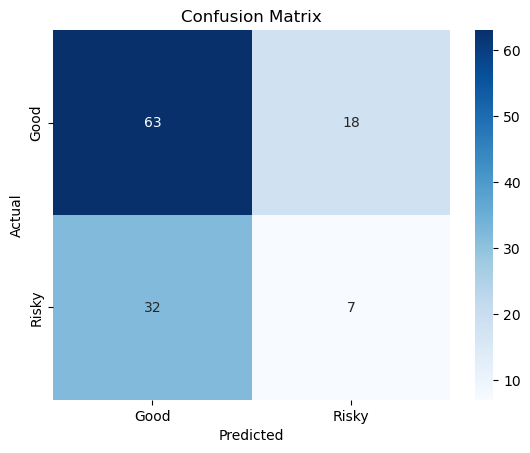

In [16]:
print("Random Forest Accuracy:", accuracy_score(y_pred,y_test))
print("Confusion Matrix", confusion_matrix(y_pred,y_test))
print("Classification Report:", classification_report(y_pred,y_test))

sns.heatmap(confusion_matrix(y_pred,y_test), annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Good', 'Risky'], 
            yticklabels=['Good', 'Risky'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [17]:
params = {
    'n_estimators':[100,200,200],
    'max_depth':[3,5,10, None],
    'min_samples_split': [2,5,10],
    'criterion':['gini','entropy']}
grid = GridSearchCV(RandomForestClassifier(random_state=42),params, cv = 5, scoring='f1', n_jobs= -1)
grid.fit(X_train,y_train)

print("Best Parameters:", grid.best_params_)
print("Best f1 score :", grid.best_score_)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
Best f1 score : 0.7140791169624717


Accuracy: 0.575

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.64      0.71        95
           1       0.19      0.32      0.24        25

    accuracy                           0.57       120
   macro avg       0.49      0.48      0.47       120
weighted avg       0.66      0.57      0.61       120



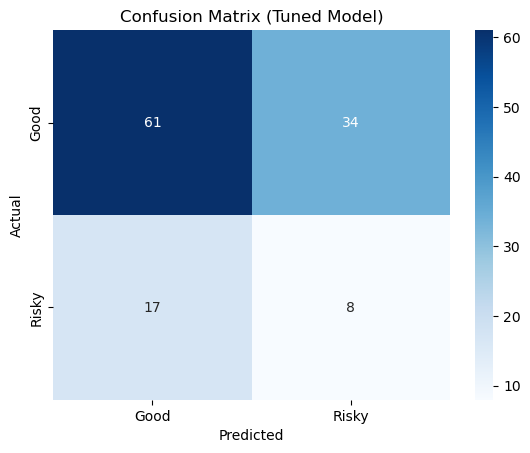

In [18]:
best_model = RandomForestClassifier(
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    n_estimators=200,
    random_state=42
)
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:')
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Risky'],
            yticklabels=['Good', 'Risky'])
plt.title('Confusion Matrix (Tuned Model)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [ ]:
features = X.columns
importances = pd.Series(best_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh', color='steelblue')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

print(importances.sort_values(ascending=False))

# 📊 Project Summary — Fraud Risk Prediction Using Random Forest
Objective
Build a classification model to predict whether a taxpayer is Risky (Taxable Income ≤ 30,000) or Good (Taxable Income > 30,000) using demographic and financial features.

# Dataset

600 rows, 6 features — Undergrad, Marital Status, Taxable Income, City Population, Work Experience, Urban
No missing values, no duplicates
Target variable created from Taxable Income — 476 Good vs 124 Risky (imbalanced)



# Key EDA Findings

Taxable Income split clearly separated Risky and Good classes as expected
Work Experience showed moderate separation between classes — useful but not decisive
Undergrad and Urban appeared visually different but on closer inspection the Risky to Good ratio was nearly identical across groups — meaning they are weak predictors
City Population and Work Experience turned out to be the strongest predictors per feature importance (48% and 32% respectively)

# Challenges

Small dataset — 600 rows is insufficient for Random Forest to learn robust patterns

Class imbalance — 80/20 split required SMOTE to generate synthetic Risky samples, which may not perfectly represent real patterns

Weak features — Undergrad and Urban added very little predictive value despite looking promising in EDA

GridSearchCV limitation — Tuning improved Risky recall but couldn't significantly boost overall accuracy because the data itself lacked enough signal

# Conclusion
The model achieved 57-58% accuracy which is modest. The core limitation is the dataset size and feature quality rather than the algorithm or tuning. In a real world scenario this could be improved by collecting more data, adding stronger financial features, and exploring ensemble methods like XGBoost which handles imbalanced small datasets better than Random Forest.